# Part 1 — Data Preparation and Exploratory Analysis

**7PAM2033 Applied Machine Learning — Assignment 2**
**Appliance Energy Prediction (UCI)**

This notebook is self-contained: place it in any folder and run all cells.
It downloads the dataset on first run and caches it alongside the notebook.

Contents:

1. Setup and configuration
2. Retrieving and auditing the raw 10-minute data
3. Aggregating to hourly resolution
4. Exploratory analysis and identification of time-series components
5. Stationarity testing (ADF, KPSS, ACF, PACF, differencing)
6. MSTL decomposition of daily and weekly seasonality
7. Summary of findings


## 1. Setup and configuration


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

# --- Paths: everything lives next to this notebook -------------------
BASE_DIR = Path.cwd()
RAW_FILE = BASE_DIR / "energydata_complete.csv"
HOURLY_FILE = BASE_DIR / "energy_hourly.csv"

FIGURE_DIR = BASE_DIR / "outputs" / "figures"
METRICS_DIR = BASE_DIR / "outputs" / "metrics"
for directory in (FIGURE_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RAW_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00374/energydata_complete.csv"
)

# --- Data constants --------------------------------------------------
TARGET = "Appliances"

# rv1 and rv2 are random variables added by the dataset authors as a control
# for feature-selection experiments. They carry no signal and are dropped.
NOISE_COLS = ["rv1", "rv2"]

RAW_FREQ = "10min"
OBS_PER_HOUR = 6          # six 10-minute readings make one complete hour

# --- Forecasting design constants ------------------------------------
DAILY_PERIOD = 24         # hours in a day
WEEKLY_PERIOD = 168       # hours in a week
HORIZON = 24              # forecast horizon required by the brief
TEST_DAYS = 14            # hold-out length required by the brief
TEST_STEPS = TEST_DAYS * DAILY_PERIOD

RANDOM_STATE = 42

# --- Plot styling ----------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 12,
})

PRIMARY = "#1f4e79"
SECONDARY = "#c0504d"
MUTED = "#7f9db9"

print(f"Working directory: {BASE_DIR}")
print("Setup complete.")


Working directory: /Users/kayode/Library/CloudStorage/OneDrive-UniversityofHertfordshire/files-2
Setup complete.


## 2. Retrieving and auditing the raw data

The file is downloaded once and cached next to the notebook, so re-running
does not repeatedly hit the UCI server.

Before any modelling we audit completeness: duplicate timestamps, missing
cells, and gaps in the 10-minute sampling grid. This is the evidence behind
the claim in the report that no imputation was necessary.


In [2]:
def load_raw(url=RAW_URL, cache=RAW_FILE):
    """Return the raw 10-minute data indexed by timestamp, caching locally."""
    if not cache.exists():
        print(f"Downloading dataset from {url} ...")
        pd.read_csv(url).to_csv(cache, index=False)
        print(f"Cached to {cache}")

    frame = pd.read_csv(cache, parse_dates=["date"])
    return frame.set_index("date").sort_index()


def audit_raw(frame):
    """Summarise completeness and regularity of the raw series."""
    expected = pd.date_range(frame.index.min(), frame.index.max(), freq=RAW_FREQ)

    return {
        "rows": len(frame),
        "columns": frame.shape[1],
        "start": frame.index.min(),
        "end": frame.index.max(),
        "duplicate_timestamps": int(frame.index.duplicated().sum()),
        "missing_cells": int(frame.isna().sum().sum()),
        "expected_timestamps": len(expected),
        "missing_timestamps": int(len(expected.difference(frame.index))),
    }


raw = load_raw()

print("Raw data audit")
print("-" * 46)
for key, value in audit_raw(raw).items():
    print(f"{key:>22}: {value}")

raw.head()


Raw data audit
----------------------------------------------
                  rows: 19735
               columns: 28
                 start: 2016-01-11 17:00:00
                   end: 2016-05-27 18:00:00
  duplicate_timestamps: 0
         missing_cells: 0
   expected_timestamps: 19735
    missing_timestamps: 0


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


The series is complete: 19,735 records spanning 2016-01-11 17:00 to
2016-05-27 18:00, with no duplicate timestamps, no missing cells and no gaps
in the 10-minute grid. Imputation is therefore not required, which removes a
source of uncertainty that would otherwise need discussing in the results.


## 3. Aggregating to hourly resolution

The brief requires hourly values. The sensor channels are instantaneous
readings, so the mean is the natural aggregator; the target is aggregated the
same way to stay consistent with the reference implementation supplied with
the brief. Because this is a fixed linear rescaling, the choice changes the
units of the error metrics but not the relative ranking of models.

Hours assembled from fewer than six readings are discarded. Only the final
hour of the record qualifies — it holds a single observation and would
otherwise sit inside the test window as a downward-biased outlier.


In [3]:
def to_hourly(frame, drop_noise=True):
    """Aggregate 10-minute readings to hourly means, dropping partial hours."""
    if drop_noise:
        frame = frame.drop(columns=[c for c in NOISE_COLS if c in frame.columns])

    counts = frame.resample("h").size()
    hourly = frame.resample("h").mean()

    incomplete = int((counts < OBS_PER_HOUR).sum())
    if incomplete:
        print(f"Dropping {incomplete} incomplete hour(s) "
              f"(fewer than {OBS_PER_HOUR} readings).")

    hourly = hourly.loc[counts >= OBS_PER_HOUR]
    return hourly.dropna(subset=[TARGET])


hourly = to_hourly(raw)
hourly.to_csv(HOURLY_FILE)

series = hourly[TARGET]

gaps = pd.date_range(series.index.min(), series.index.max(),
                     freq="h").difference(series.index)

print(f"Hourly shape : {hourly.shape}")
print(f"Hourly range : {series.index.min()} to {series.index.max()}")
print(f"Hourly gaps  : {len(gaps)}")
print(f"Saved        : {HOURLY_FILE.name}")


Dropping 1 incomplete hour(s) (fewer than 6 readings).
Hourly shape : (3289, 26)
Hourly range : 2016-01-11 17:00:00 to 2016-05-27 17:00:00
Hourly gaps  : 0
Saved        : energy_hourly.csv


In [4]:
print("Target summary statistics")
print("-" * 46)
print(series.describe().round(2).to_string())
print(f"{'skew':>22}: {series.skew():.3f}")

print(f"\nTrain hours: {len(series) - TEST_STEPS}   Test hours: {TEST_STEPS}")
print(f"Test window begins: {series.index[-TEST_STEPS]}")


Target summary statistics
----------------------------------------------
count    3289.00
mean       97.68
std        81.02
min        28.33
25%        50.00
50%        63.33
75%       110.00
max       608.33
                  skew: 2.389

Train hours: 2953   Test hours: 336
Test window begins: 2016-05-13 18:00:00


count    3289.00
mean       97.68
std        81.02
min        28.33
25%        50.00
50%        63.33
75%       110.00
max       608.33
                  skew: 2.389

Train hours: 2953   Test hours: 336
Test window begins: 2016-05-13 18:00:00


## 4. Exploratory analysis

### 4.1 Series overview

At full extent the 3,289 hourly points overplot into a solid band, so a
two-week detail panel is included to make the underlying cycle legible.


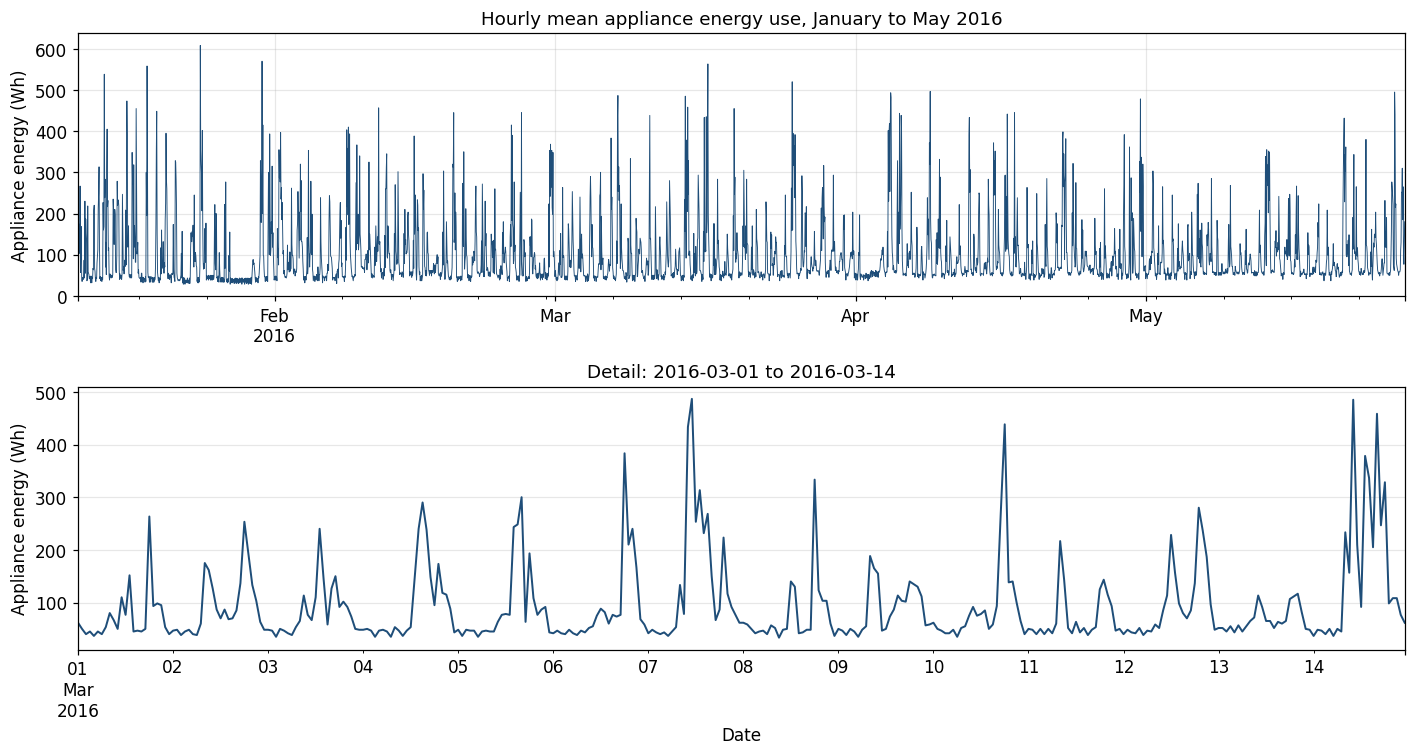

In [5]:
def plot_series_overview(s, detail=("2016-03-01", "2016-03-14")):
    """Full series plus a two-week detail window."""
    fig, axes = plt.subplots(2, 1, figsize=(13, 7))

    s.plot(ax=axes[0], linewidth=0.6, color=PRIMARY)
    axes[0].set(title="Hourly mean appliance energy use, January to May 2016",
                ylabel="Appliance energy (Wh)", xlabel="")

    s.loc[detail[0]:detail[1]].plot(ax=axes[1], linewidth=1.3, color=PRIMARY)
    axes[1].set(title=f"Detail: {detail[0]} to {detail[1]}",
                ylabel="Appliance energy (Wh)", xlabel="Date")

    fig.tight_layout()
    return fig


fig = plot_series_overview(series)
fig.savefig(FIGURE_DIR / "01_series_overview.png")
plt.show()


The series is spiky rather than smooth: long stretches near a baseline of
roughly 50 Wh, punctuated by sharp excursions above 400 Wh. This is the
signature of discrete appliance switching events rather than a continuously
varying load, and it is the single most important feature of the data for
model selection. There is no visible long-run trend, though the winter months
sit on a slightly higher baseline than May.

### 4.2 Distribution of the target


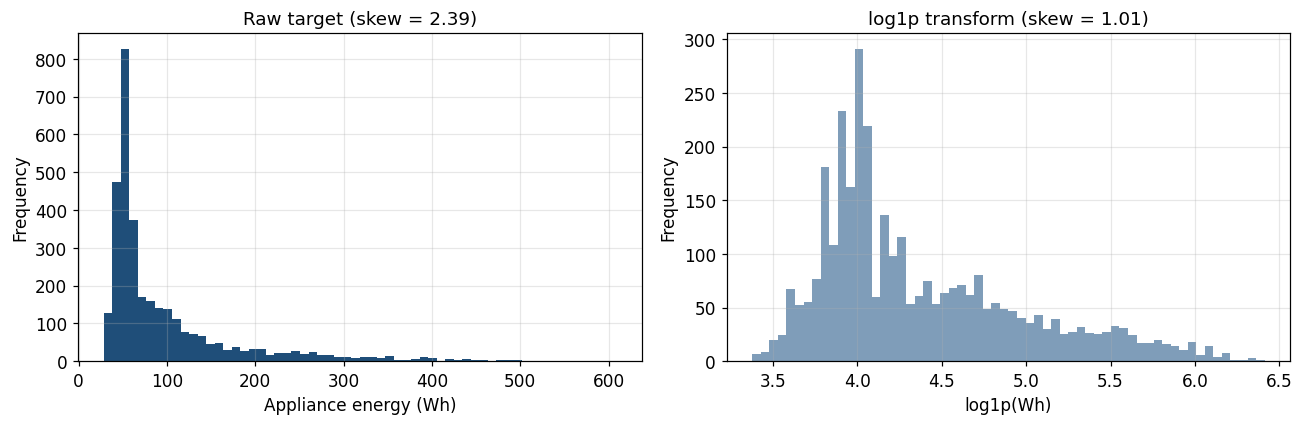

In [6]:
def plot_distribution(s):
    """Raw and log1p distributions, annotated with skewness."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(s, bins=60, color=PRIMARY)
    axes[0].set(title=f"Raw target (skew = {s.skew():.2f})",
                xlabel="Appliance energy (Wh)", ylabel="Frequency")

    axes[1].hist(np.log1p(s), bins=60, color=MUTED)
    axes[1].set(title=f"log1p transform (skew = {np.log1p(s).skew():.2f})",
                xlabel="log1p(Wh)", ylabel="Frequency")

    fig.tight_layout()
    return fig


fig = plot_distribution(series)
fig.savefig(FIGURE_DIR / "02_distribution.png")
plt.show()


Strong right skew (2.39); a `log1p` transform reduces this to about 1.0.
This matters for evaluation design: squared-error losses are dominated by the
rare large values, so RMSE will largely measure how well each model handles
peaks rather than typical behaviour. MAE and MASE are reported alongside it in
Part 8 for that reason.

### 4.3 Seasonal profiles


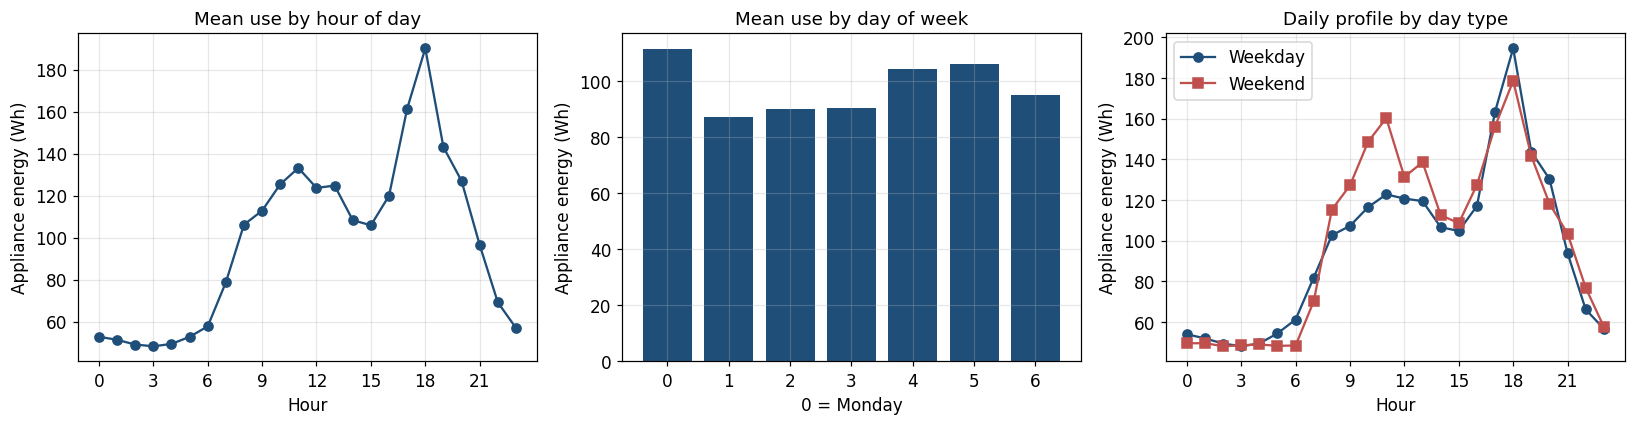

In [7]:
def plot_seasonal_profiles(frame, target=TARGET):
    """Average demand by hour of day, by day of week, and the two combined."""
    work = frame.assign(hour=frame.index.hour, dayofweek=frame.index.dayofweek)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    hourly_mean = work.groupby("hour")[target].mean()
    axes[0].plot(hourly_mean.index, hourly_mean.values, marker="o", color=PRIMARY)
    axes[0].set(title="Mean use by hour of day", xlabel="Hour",
                ylabel="Appliance energy (Wh)", xticks=range(0, 24, 3))

    dow_mean = work.groupby("dayofweek")[target].mean()
    axes[1].bar(dow_mean.index, dow_mean.values, color=PRIMARY)
    axes[1].set(title="Mean use by day of week", xlabel="0 = Monday",
                ylabel="Appliance energy (Wh)")

    weekday = work[work["dayofweek"] < 5].groupby("hour")[target].mean()
    weekend = work[work["dayofweek"] >= 5].groupby("hour")[target].mean()
    axes[2].plot(weekday.index, weekday.values, marker="o",
                 color=PRIMARY, label="Weekday")
    axes[2].plot(weekend.index, weekend.values, marker="s",
                 color=SECONDARY, label="Weekend")
    axes[2].set(title="Daily profile by day type", xlabel="Hour",
                ylabel="Appliance energy (Wh)", xticks=range(0, 24, 3))
    axes[2].legend()

    fig.tight_layout()
    return fig


fig = plot_seasonal_profiles(hourly)
fig.savefig(FIGURE_DIR / "03_seasonal_profiles.png")
plt.show()


The daily profile is bimodal: a broad late-morning plateau and a sharp evening
peak near 18:00 roughly four times the overnight baseline. Day-of-week
variation is weaker but not absent, with Monday and the Thursday–Friday pair
running higher than Tuesday and Wednesday.

Splitting the daily profile by day type shows *where* the weekly effect lives.
Weekends and weekdays share the same evening peak, but weekend mornings and
midday are substantially higher. A weekly seasonal model therefore has real
structure to capture, even though it is secondary to the daily cycle.

### 4.4 Relationship with the covariates


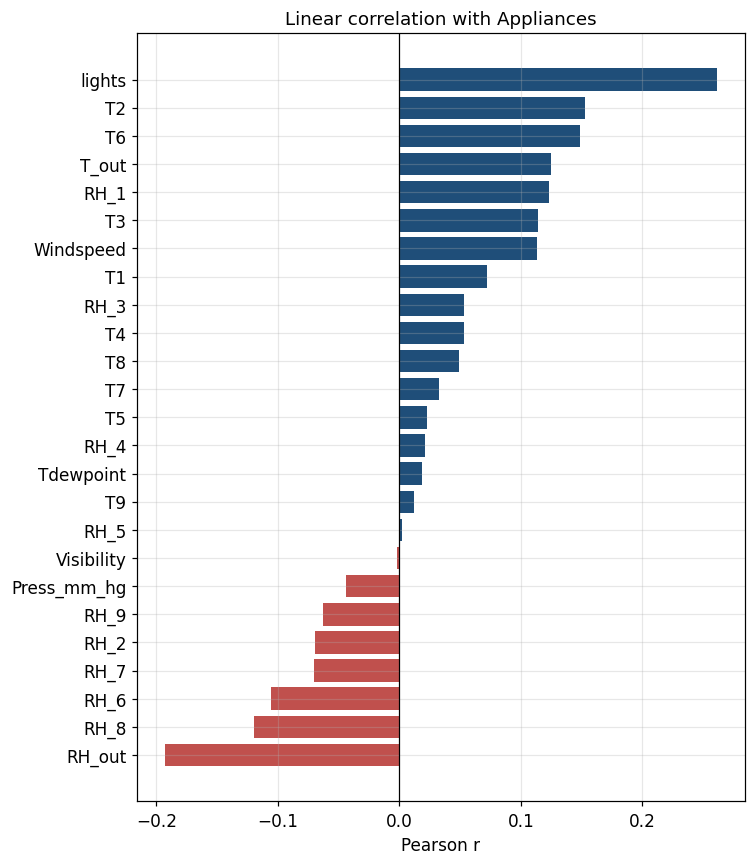

Strongest linear correlates:
lights    0.261
RH_out   -0.193
T2        0.153
T6        0.149
T_out     0.124
RH_1      0.123
RH_8     -0.120
T3        0.114


In [8]:
def plot_correlation_with_target(frame, target=TARGET):
    """Rank every numeric column by its linear correlation with the target."""
    corr = frame.corr(numeric_only=True)[target].drop(target).sort_values()

    fig, ax = plt.subplots(figsize=(7, 8))
    colours = [SECONDARY if v < 0 else PRIMARY for v in corr.values]
    ax.barh(corr.index, corr.values, color=colours)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title=f"Linear correlation with {target}", xlabel="Pearson r")

    fig.tight_layout()
    return fig, corr


fig, corr = plot_correlation_with_target(hourly)
fig.savefig(FIGURE_DIR / "05_correlation_with_target.png")
plt.show()

print("Strongest linear correlates:")
print(corr.reindex(corr.abs().sort_values(ascending=False).index)
          .head(8).round(3).to_string())


No individual sensor or weather channel is strongly related to the target —
the largest absolute correlation is about 0.26. This is early evidence that
the lagged target will carry most of the predictive weight, and it frames the
covariate discussion in Parts 5 and 6.

## 5. Stationarity testing

ADF and KPSS state opposite null hypotheses, which is why they are run as a
pair rather than individually:

- **ADF** — H₀: a unit root is present. A small p-value favours stationarity.
- **KPSS** — H₀: the series is stationary. A large p-value favours stationarity.

Agreement between the two is stronger evidence than either test alone.


In [9]:
def stationarity_report(s, label):
    """Run ADF and KPSS on one series and return a tidy record."""
    clean = s.dropna()

    adf_stat, adf_p, adf_lags, *_ = adfuller(clean, autolag="AIC")
    kpss_stat, kpss_p, kpss_lags, _ = kpss(clean, regression="c", nlags="auto")

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = "stationary (both agree)"
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        verdict = "non-stationary (both agree)"
    else:
        verdict = "ambiguous (tests disagree)"

    return {"series": label, "n": len(clean),
            "ADF stat": round(adf_stat, 3), "ADF p": adf_p,
            "KPSS stat": round(kpss_stat, 3), "KPSS p": kpss_p,
            "verdict": verdict}


def stationarity_table(s, seasonal_period=DAILY_PERIOD):
    """Test the level series and its differenced variants.

    Differencing an already-stationary series is a modelling error, so this
    table exists to demonstrate that differencing is unnecessary rather than
    to justify applying it.
    """
    variants = [
        (s, "Level"),
        (s.diff(), "First difference (d=1)"),
        (s.diff(seasonal_period), f"Seasonal difference (D=1, s={seasonal_period})"),
        (s.diff().diff(seasonal_period), "First + seasonal difference"),
    ]
    return pd.DataFrame([stationarity_report(v, label) for v, label in variants])


stationarity = stationarity_table(series)
stationarity.to_csv(METRICS_DIR / "stationarity_tests.csv", index=False)

printable = stationarity[["series", "ADF stat", "ADF p",
                          "KPSS stat", "KPSS p", "verdict"]].copy()
printable["ADF p"] = printable["ADF p"].map(lambda v: f"{v:.3g}")
printable["KPSS p"] = printable["KPSS p"].map(lambda v: f"{v:.3g}")
print(printable.to_string(index=False))


                         series  ADF stat    ADF p  KPSS stat KPSS p                 verdict
                          Level    -9.085 3.97e-15      0.041    0.1 stationary (both agree)
         First difference (d=1)   -16.934 9.72e-30      0.020    0.1 stationary (both agree)
Seasonal difference (D=1, s=24)   -13.643 1.64e-25      0.007    0.1 stationary (both agree)
    First + seasonal difference   -17.994 2.75e-30      0.044    0.1 stationary (both agree)


**The level series is already stationary.** ADF rejects the unit root
decisively and KPSS fails to reject stationarity, so both tests agree without
any differencing.

This follows from the structure of the data: appliance demand always returns
to the same overnight baseline, so the series is mean-reverting by
construction. The differenced variants are also stationary, but differencing
an already-stationary series introduces an unnecessary moving-average
component and inflates the noise. The implication for Part 4 is that we should
expect **d = 0**, and a grid search selecting d > 0 should be treated with
suspicion.

### 5.1 ACF and PACF


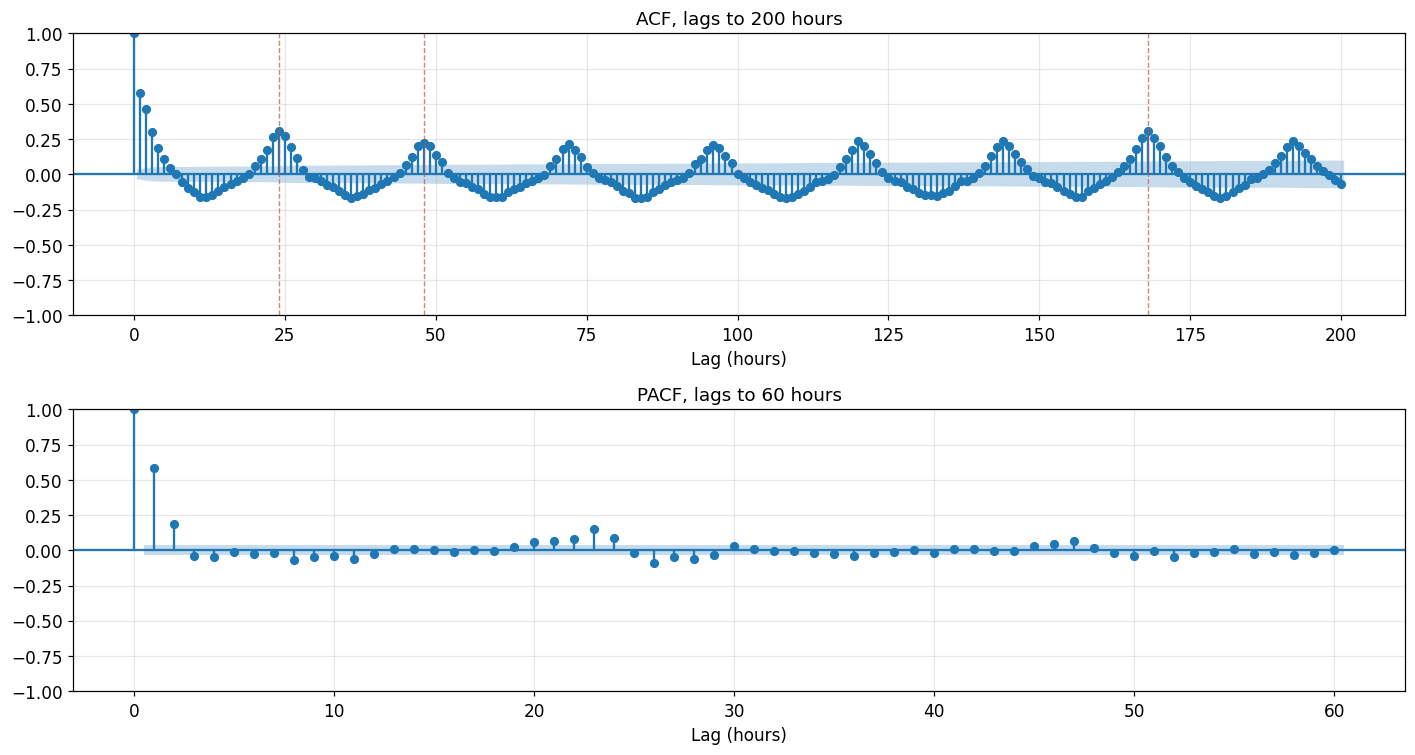

,lag,interpretation,acf
0,1,1 hour (naive),0.581
1,24,24 hours (daily seasonal naive),0.304
2,48,48 hours,0.221
3,168,168 hours (weekly seasonal naive),0.306


In [10]:
def plot_acf_pacf(s, acf_lags=200, pacf_lags=60):
    """ACF over several seasonal cycles, PACF over the short-lag region."""
    fig, axes = plt.subplots(2, 1, figsize=(13, 7))

    plot_acf(s.dropna(), lags=acf_lags, ax=axes[0])
    axes[0].set(title=f"ACF, lags to {acf_lags} hours", xlabel="Lag (hours)")
    for lag in (DAILY_PERIOD, 2 * DAILY_PERIOD, WEEKLY_PERIOD):
        if lag <= acf_lags:
            axes[0].axvline(lag, color=SECONDARY, linestyle="--",
                            linewidth=0.9, alpha=0.7)

    plot_pacf(s.dropna(), lags=pacf_lags, method="ywm", ax=axes[1])
    axes[1].set(title=f"PACF, lags to {pacf_lags} hours", xlabel="Lag (hours)")

    fig.tight_layout()
    return fig


def key_autocorrelations(s):
    """Autocorrelation at the lags corresponding to the benchmark models."""
    values = acf(s.dropna(), nlags=WEEKLY_PERIOD)
    lags = {
        1: "1 hour (naive)",
        DAILY_PERIOD: "24 hours (daily seasonal naive)",
        2 * DAILY_PERIOD: "48 hours",
        WEEKLY_PERIOD: "168 hours (weekly seasonal naive)",
    }
    return pd.DataFrame([{"lag": k, "interpretation": v, "acf": round(values[k], 3)}
                         for k, v in lags.items()])


fig = plot_acf_pacf(series)
fig.savefig(FIGURE_DIR / "04_acf_pacf.png")
plt.show()

key_acf = key_autocorrelations(series)
key_acf.to_csv(METRICS_DIR / "key_autocorrelations.csv", index=False)
key_acf


The ACF shows a clean 24-hour oscillation still visible at lag 200, confirming
persistent daily seasonality rather than a decaying transient. The seasonal
peaks do not die away, which is the signature of deterministic rather than
stochastic seasonality.

Autocorrelation at lag 168 is essentially identical to lag 24. The weekly
benchmark is therefore competitive with the daily one on this evidence alone —
a point returned to in the report's first question.

The PACF cuts off sharply after roughly lag 2–3, with a further spike near
lag 23–24. This suggests a low-order non-seasonal AR term combined with a
seasonal term at s = 24, which is the region the Part 4 grid search should
concentrate on.

## 6. MSTL decomposition

Classical decomposition accepts a single period. Appliance demand carries both
a daily and a weekly rhythm, so MSTL is used to estimate them jointly rather
than forcing a choice. Component strength is reported on the
Hyndman–Athanasopoulos scale, 1 − Var(remainder) / Var(component + remainder).


    seasonal_24h: 0.474
   seasonal_168h: 0.298
           trend: 0.046


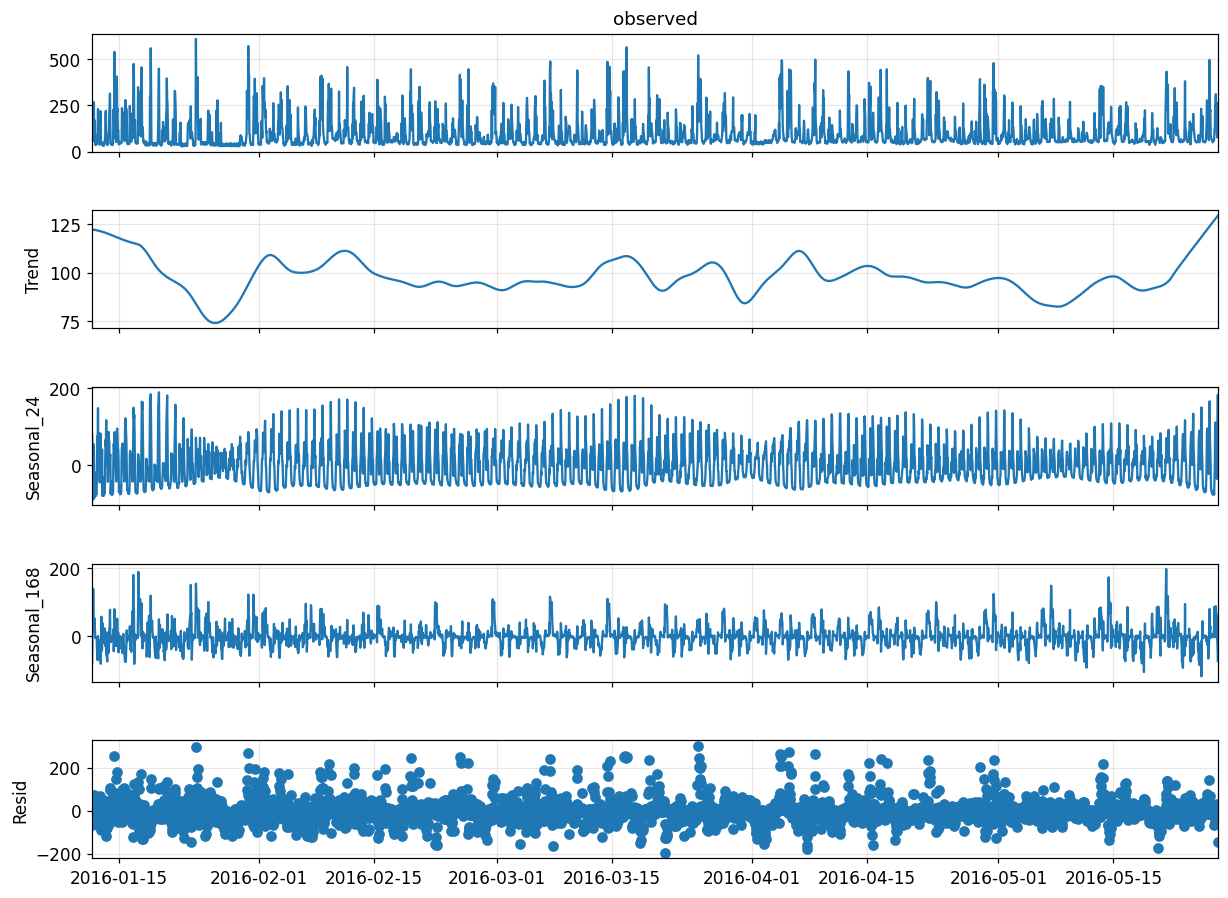

In [11]:
def seasonal_strength(component, remainder):
    """Component strength: 1 - Var(remainder) / Var(component + remainder)."""
    denominator = (component + remainder).var()
    if denominator == 0:
        return float("nan")
    return float(np.clip(1 - remainder.var() / denominator, 0, 1))


def run_mstl(s, periods=(DAILY_PERIOD, WEEKLY_PERIOD)):
    """Multiple-seasonal decomposition separating daily and weekly cycles."""
    result = MSTL(s, periods=periods).fit()

    strengths = {}
    seasonal = result.seasonal
    for index, period in enumerate(periods):
        component = seasonal.iloc[:, index] if seasonal.ndim > 1 else seasonal
        strengths[f"seasonal_{period}h"] = seasonal_strength(component, result.resid)
    strengths["trend"] = seasonal_strength(result.trend, result.resid)

    return result, strengths


mstl_result, strengths = run_mstl(series)

for component, value in strengths.items():
    print(f"{component:>16}: {value:.3f}")

pd.Series(strengths, name="strength").to_frame().to_csv(
    METRICS_DIR / "decomposition_strengths.csv"
)

fig = mstl_result.plot()
fig.set_size_inches(12, 9)
fig.savefig(FIGURE_DIR / "06_mstl_decomposition.png", bbox_inches="tight")
plt.show()


### Components identified

| Component | Strength | Interpretation |
|---|---|---|
| Daily (24 h) | 0.47 | Moderate, and the dominant cycle |
| Weekly (168 h) | 0.30 | Present but secondary |
| Trend | 0.05 | Negligible |

The near-zero trend strength corroborates the stationarity tests. Neither
seasonal component is overwhelming: a strength of 0.47 means well over half
the variance remains in the remainder once both cycles are removed. That
remainder is the irregular appliance-switching behaviour visible in the
overview plot, and it places a ceiling on how well any purely seasonal model
can perform — the key expectation to carry into Parts 3 to 7.

## 7. Summary of Part 1

- 19,735 complete 10-minute records; no gaps, duplicates or missing values
- Aggregated to 3,289 hourly observations after dropping one incomplete hour
- Split: 2,953 training hours, final 336 hours (14 days) held out for testing
- Target strongly right-skewed (skew 2.39); spikes will dominate RMSE
- Series stationary in levels, ADF and KPSS agreeing, so **d = 0** expected
- Daily seasonality dominant (0.47), weekly secondary (0.30), trend negligible (0.05)
- ACF at lag 168 matches lag 24, so daily and weekly benchmarks should be close
- PACF suggests low-order AR terms plus a seasonal term at s = 24
- No covariate exceeds |r| = 0.26 with the target

Outputs written to `outputs/figures/` and `outputs/metrics/`; the prepared
hourly dataset is saved as `energy_hourly.csv`.
